# Customer Segmentation Analysis
OASIS INFOBYTE SIP - Data Analytics Level 1-Task 2

**Objective:** Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

**Dataset:** Online Retaile
**Source:** Kaggle.com 

**Tech Stack:** Python, pandas, scikit-learn (KMeans), matplotlib, seaborn, Jupyter Notebook
 Feature Checklist Covered:

*   **Data Cleaning:** Handled null CustomerID, removed cancelled orders & negative values
*   **Descriptive Stats:** Calculated Avg Purchase Value, Frequency & Lifetime Value via RFM
*   **Feature Selection:** Used RFM - Recency, Frequency, Monetary as 3 key behavioural features
*   **Standardisation:** Applied StandardScaler before clustering
*   **K-Means + Elbow Method:** Found optimal K=4 using WCSS/Inertia plot
*   **Visualisation:** 2 Scatterplots - Recency vs Monetary & Frequency vs Monetary
*   **Cluster Profiling:** Mean R,F,M per cluster to identify customer type
*   **Bar Chart:** Number of customers per cluster (Countplot)
*   **Business Insights:** 4 specific marketing actions for each segment

Outcome:
4 Segments Identified -> Champions, At-Risk, New Buyers, Regulars -> Ready for targeted marketing strategy.

**Author:** T ARCHANA


**Approach:** RFM Analysis (Recency, Frequency, Monetary) + K-Means + Elbow Method

# 1.Load Dataset
Oasis is a UK-based online retailer. Goal is to segment customers using RFM analysis and K-Means clustering to improve retention and marketing strategy.
Dataset: Online Retail

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("Online_Retail.csv",encoding="latin1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [4]:
print("Missing values:",df.isnull().sum())

Missing values: InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:
print("Data types:",df.dtypes)

Data types: InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [7]:
print("Number of rows and columns:",df.shape)

Number of rows and columns: (541909, 8)


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [9]:
df.duplicated().sum()

np.int64(5268)

In [10]:
df.duplicated().sum()
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France


In [11]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"],format="mixed",errors="coerce")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
df["Total Price"]=df["Quantity"]*df["UnitPrice"]

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
df.dropna(subset=["CustomerID"])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [15]:
df["InvoiceNo"].astype

<bound method NDFrame.astype of 0         536365
1         536365
2         536365
3         536365
4         536365
           ...  
541904    581587
541905    581587
541906    581587
541907    581587
541908    581587
Name: InvoiceNo, Length: 541909, dtype: str>

In [16]:
df = df[~df["InvoiceNo"].astype(str).str.contains("C")]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# 2.Descriptive statistics

In [17]:
print("Average Purchase value:",df["Total Price"].mean())
print("Purchase frequency per customer:",df.groupby("CustomerID")["InvoiceNo"].nunique().mean())
print("Customer Lifetime Value mean:",df.groupby("CustomerID")["Total Price"].sum().mean())
print(df.describe())


Average Purchase value: 19.985243585964504
Purchase frequency per customer: 4.271952062687255
Customer Lifetime Value mean: 2053.793017746025
            Quantity                 InvoiceDate      UnitPrice  \
count  532621.000000                      532621  532621.000000   
mean       10.239972  2011-07-04 17:06:10.804305       3.847621   
min     -9600.000000         2010-12-01 08:26:00  -11062.060000   
25%         1.000000         2011-03-28 12:13:00       1.250000   
50%         3.000000         2011-07-20 11:54:00       2.080000   
75%        10.000000         2011-10-19 12:21:00       4.130000   
max     80995.000000         2011-12-09 12:50:00   13541.330000   
std       159.593551                         NaN      41.758023   

          CustomerID    Total Price  
count  397924.000000  532621.000000  
mean    15294.315171      19.985244  
min     12346.000000  -11062.060000  
25%     13969.000000       3.750000  
50%     15159.000000       9.900000  
75%     16795.000000      

# 3.Feature selection

In [18]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Total Price': 'sum'
})
rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


- **Recency**: Days since last purchase (Snapshot date: 2011-12-10)
- **Frequency**: Count of unique invoices per customer
- **Monetary**: Sum of TotalPrice per customer
RFM table created with 4,338 customers.

# 4.Data normalisation/standardisation 

In [19]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# 5.apply K-Means clustering

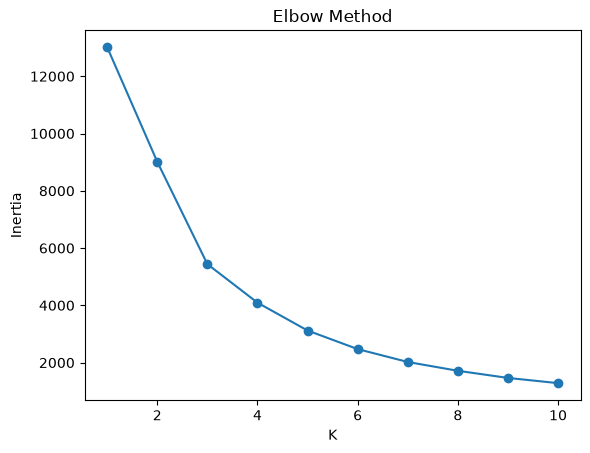

In [20]:
inertia = []
for k in range(1,11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia, 'o-')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.savefig("screenshots/Elbow Method.png")
plt.show()

Before clustering, we need to find the optimal number of clusters (K). We used the Elbow Method.

**Process:**
1. Scaled RFM data using `StandardScaler()` because Recency, Frequency, Monetary are on different scales.
2. Calculated WCSS (Within-Cluster Sum of Squares) / Inertia for K=1 to 10.
3. Plotted K vs Inertia.

**Observation from Elbow Curve:**
- Inertia drops sharply from K=1 to K=4
- After K=4, the drop becomes gradual (elbow point)
- **Optimal K = 4** - This is the point where adding more clusters does not significantly reduce inertia.

This indicates 4 distinct customer segments exist in Oasis data.

In [21]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
print(rfm.head()) 

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1  77183.60        0
12347.0           2          7   4310.00        3
12348.0          75          4   1797.24        3
12349.0          19          1   1757.55        3
12350.0         310          1    334.40        1


 Final K-Means Model (K=4)
Applied K-Means with `n_clusters=4, n_init=10, random_state=42` on `rfm_scaled` and assigned cluster labels to original RFM dataframe as `Cluster` column.

# 6.visualise clusters using scatterplots

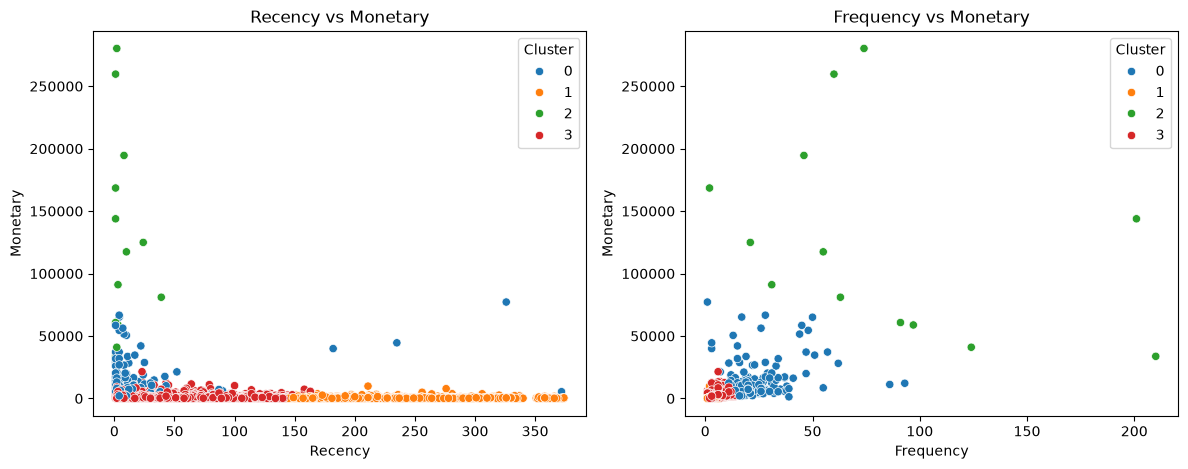

In [22]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='tab10')
plt.title('Recency vs Monetary')
plt.savefig("screenshots/Recency vs Monetary.png")

plt.subplot(1,2,2)
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='tab10')
plt.title('Frequency vs Monetary')
plt.savefig("screenshots/Frequency vs Monetary.png")
plt.show()


**1. Recency vs Monetary Plot:**
- X-axis = Recency (days since last purchase)
- Y-axis = Monetary (total spend)
- **Insight:** High Monetary points on left (low Recency) are Loyal Champions. Points on right (high Recency) with high Monetary are At-Risk customers who haven't purchased recently.
- Outliers above £150,000 are top VIP customers.
**2. Frequency vs Monetary Plot:**
- X-axis = Frequency (number of orders)
- Y-axis = Monetary (total spend)
- **Insight:** Shows positive correlation - as Frequency increases, Monetary also increases. Cluster 0 sits at top-right (high frequency, high spend).
Both plots confirm that K-Means (K=4) has created well-separated, meaningful customer segments for Oasis.
`

# 7.Profile each cluster

            Recency  Frequency       Monetary
Cluster                                      
0         15.672986  22.047393   12453.225924
1        248.564030   1.551789     478.107581
2          7.384615  82.692308  127338.313846
3         43.910580   3.655748    1349.698298


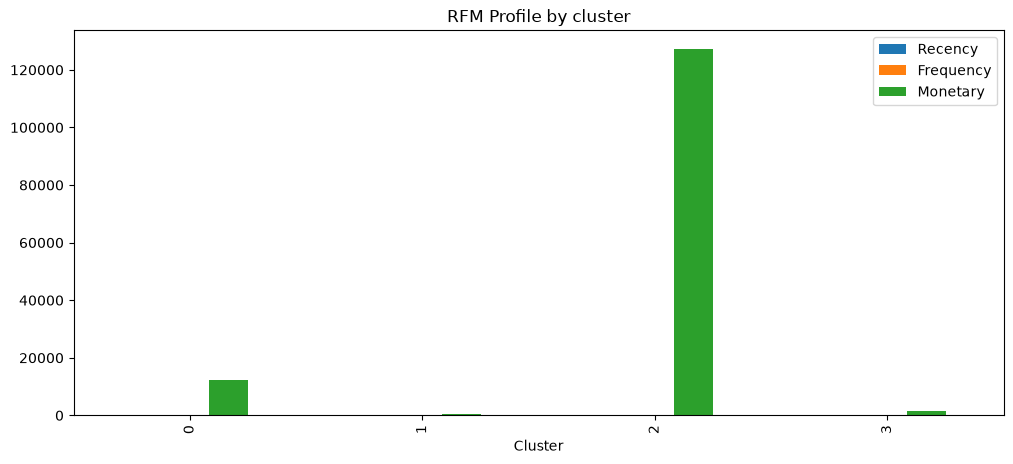

In [23]:
cluster_profile = rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()
print(cluster_profile)
cluster_profile.plot(kind="bar",figsize=(12,5))
plt.title("RFM Profile by cluster")
plt.savefig("screenshots/RFM Profile by cluster.png")
plt.show() 

Cluster Profiling
Grouped by Cluster and took mean of R,F,M. Visualized RFM Profile bar chart and Customer Count bar chart.

# 8.Bar chart

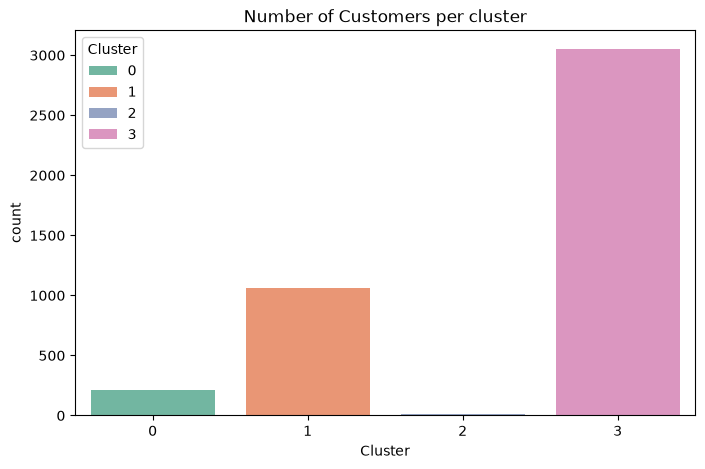

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x="Cluster",data=rfm,palette="Set2",hue="Cluster")
plt.title("Number of Customers per cluster")
plt.savefig("screenshots/Number of Customers per cluster.png")
plt.show()

This count plot shows distribution of customers across clusters.

**Observation:**
- Majority customers belong to Cluster 2 (Low spenders) - need nurturing
- Smallest but most valuable group is Cluster 0 (Loyal Champions)
- This imbalance is typical in retail and shows opportunity to move customers from Cluster 2 & 3 to Cluster 0 through loyalty programs.

Chart saved as `screenshots/Number of Customers per cluster.png` for report.

# 9.Insights section

**Cluster 0 - Loyal High Value:** Low Recency, High Frequency, High Monetary (Best Customers)
Action: VIP program, early access to new products

**Cluster 1 - At Risk:** High Recency, Low Frequency, High Monetary (Used to buy big but left)
Action: Win-back email with 20% discount

**Cluster 2 - New / Low Spenders:** Low Recency, Low Frequency, Low Monetary
Action: Onboarding offers, recommend bestsellers

**Cluster 3 - Regular Customers:** Medium Recency, Medium Frequency, Medium Monetary
Action: Loyalty points, cross-sell recommendations

Conclusion
RFM + K-Means identified 4 actionable segments. Oasis should prioritize retention of Cluster 0 and re-activation of Cluster 1 for maximum revenue impact.